# Iowa Housing — Features & Model

**Person 2 notebook.**  
This notebook builds, evaluates, and exports the machine-learning model for the Iowa House-Prices Kaggle dataset.  
Target variable: `SalePrice`. We use exactly 7 hand-picked features throughout.

## Step 1 — Load Data & Select Features

Load `data/train.csv`, define the 7 required features, build `X` (feature matrix) and `y` (target vector), then confirm shapes and column names.

In [1]:
import pandas as pd

# Constants
FEATURES = [
    'LotArea',
    'YearBuilt',
    '1stFlrSF',
    '2ndFlrSF',
    'FullBath',
    'BedroomAbvGr',
    'TotRmsAbvGrd',
]
TARGET = 'SalePrice'

# Load
df = pd.read_csv('data/train.csv')

# Build X and y
X = df[FEATURES]
y = df[TARGET]

# Confirm
print('Dataset shape  :', df.shape)
print('X shape        :', X.shape)
print('y shape        :', y.shape)
print()
print('Features present:', list(X.columns))
print()
print('All 7 features in X?', all(f in X.columns for f in FEATURES))
print()
X.head()

Dataset shape  : (1460, 81)
X shape        : (1460, 7)
y shape        : (1460,)

Features present: ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']

All 7 features in X? True



,LotArea,YearBuilt,1stFlrSF,2ndFlrSF,FullBath,BedroomAbvGr,TotRmsAbvGrd
0,8450,2003,856,854,2,3,8
1,9600,1976,1262,0,2,3,6
2,11250,2001,920,866,2,3,6
3,9550,1915,961,756,1,3,7
4,14260,2000,1145,1053,2,4,9


## Step 2 — Justify the Features

For each of the 7 features we print its Pearson correlation with `SalePrice` and give a one-line rationale to use in the presentation.

In [2]:
# Correlations with SalePrice
correlations = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)

reasons = {
    'LotArea'     : 'Larger lots command a premium — more land = more value.',
    'YearBuilt'   : 'Newer homes are in better condition and built to modern standards.',
    '1stFlrSF'    : 'First-floor square footage is the primary driver of interior space.',
    '2ndFlrSF'    : 'Additional floor area directly increases livable space and price.',
    'FullBath'    : 'Full bathrooms are a key buyer priority — strong proxy for quality.',
    'BedroomAbvGr': 'Bedroom count is one of the first filters buyers use when searching.',
    'TotRmsAbvGrd': 'Total rooms capture overall house size beyond just bedrooms.',
}

print(f'{"Feature":<15} {"Correlation":>12}   Reason')
print('-' * 80)
for feat, corr in correlations.items():
    print(f'{feat:<15} {corr:>12.4f}   {reasons[feat]}')


Feature          Correlation   Reason
--------------------------------------------------------------------------------
LotArea               0.2638   Larger lots command a premium — more land = more value.
YearBuilt             0.5229   Newer homes are in better condition and built to modern standards.
1stFlrSF              0.6059   First-floor square footage is the primary driver of interior space.
2ndFlrSF              0.3193   Additional floor area directly increases livable space and price.
FullBath              0.5607   Full bathrooms are a key buyer priority — strong proxy for quality.
BedroomAbvGr          0.1682   Bedroom count is one of the first filters buyers use when searching.
TotRmsAbvGrd          0.5337   Total rooms capture overall house size beyond just bedrooms.


## Step 3 — Handle Missing Values

Check `X.isna().sum()` for each of the 7 features. If any column has nulls, fill them with the column median. Show the before and after counts.

In [3]:
# Before: count nulls per feature
missing_before = X.isna().sum()
print('=== Missing values BEFORE fill ===')
print(missing_before)
print()

# Fill nulls with column median (only touches columns that need it)
X = X.fillna(X.median())

# After: confirm zeros
missing_after = X.isna().sum()
print('=== Missing values AFTER fill ===')
print(missing_after)
print()
print('Any nulls remaining?', X.isna().any().any())


=== Missing values BEFORE fill ===
LotArea         0
YearBuilt       0
1stFlrSF        0
2ndFlrSF        0
FullBath        0
BedroomAbvGr    0
TotRmsAbvGrd    0
dtype: int64

=== Missing values AFTER fill ===
LotArea         0
YearBuilt       0
1stFlrSF        0
2ndFlrSF        0
FullBath        0
BedroomAbvGr    0
TotRmsAbvGrd    0
dtype: int64

Any nulls remaining? False


## Step 4 — Train / Test Split

Split `X` and `y` into 80 % training and 20 % test sets using `random_state=1` for reproducibility. Print all four resulting shapes.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test  shape:', y_test.shape)
print()
print('Train rows:', len(X_train), '| Test rows:', len(X_test))
print('Split ratio: {:.0f}/{:.0f}'.format(
    100 * len(X_train) / len(X),
    100 * len(X_test)  / len(X)
))


X_train shape: (1168, 7)
X_test  shape: (292, 7)
y_train shape: (1168,)
y_test  shape: (292,)

Train rows: 1168 | Test rows: 292
Split ratio: 80/20


## Step 5 — Baseline Model

A naive baseline that predicts the **median `SalePrice`** of the training set for every house. Its MAE on the test set is the benchmark every real model must beat.

In [5]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Baseline: always predict the training-set median
median_price = y_train.median()
baseline_preds = np.full(shape=len(y_test), fill_value=median_price)

baseline_mae = mean_absolute_error(y_test, baseline_preds)

print('Training-set median SalePrice : ${:,.0f}'.format(median_price))
print('Baseline MAE (test set)       : ${:,.0f}'.format(baseline_mae))
print()
print('=> Any real model must achieve MAE < ${:,.0f} to beat the baseline.'.format(baseline_mae))


Training-set median SalePrice : $164,945
Baseline MAE (test set)       : $56,621

=> Any real model must achieve MAE < $56,621 to beat the baseline.


## Step 6 — Train Two Models

Train a **Decision Tree** and a **Random Forest** on the training set using the exact hyperparameters specified. Confirm both fit successfully.

In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Decision Tree
dt_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=5,
    random_state=1
)
dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=1,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

print('Decision Tree  -> fitted:', hasattr(dt_model, 'tree_'))
print('  max_depth=8, min_samples_leaf=5, random_state=1')
print()
print('Random Forest  -> fitted:', hasattr(rf_model, 'estimators_'))
print('  n_estimators=300, min_samples_leaf=2, random_state=1, n_jobs=-1')
print()
print('Both models trained successfully!')


Decision Tree  -> fitted: True
  max_depth=8, min_samples_leaf=5, random_state=1

Random Forest  -> fitted: True
  n_estimators=300, min_samples_leaf=2, random_state=1, n_jobs=-1

Both models trained successfully!


## Step 7 — Evaluate & Compare

Compute **MAE**, **RMSE**, and **R²** on the test set for all three models (Baseline, Decision Tree, Random Forest) and display a clean comparison table.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = [
    evaluate('Baseline',      y_test, baseline_preds),
    evaluate('Decision Tree', y_test, dt_model.predict(X_test)),
    evaluate('Random Forest', y_test, rf_model.predict(X_test)),
]

import pandas as pd
results_df = pd.DataFrame(results).set_index('Model')

# Pretty-print
print('{:<15} {:>12} {:>12} {:>8}'.format('Model', 'MAE ($)', 'RMSE ($)', 'R2'))
print('-' * 52)
for idx, row in results_df.iterrows():
    print('{:<15} {:>12,.0f} {:>12,.0f} {:>8.4f}'.format(
        idx, row['MAE'], row['RMSE'], row['R2']))

print()
results_df


Model                MAE ($)     RMSE ($)       R2
----------------------------------------------------
Baseline              56,621       85,142  -0.0164
Decision Tree         26,968       40,787   0.7667
Random Forest         22,394       33,526   0.8424



,MAE,RMSE,R2
Model,,,
Baseline,56621.147260,85142.119894,-0.016438
Decision Tree,26968.238223,40786.705916,0.766746
Random Forest,22394.175551,33525.947826,0.842401


## Step 8 — Pick the Final Model

Select the model with the **lowest MAE** on the test set. We don’t assume a winner — we let the numbers decide.

In [8]:
# Map model names to (model object, MAE)
candidates = {
    'Decision Tree': (dt_model, results_df.loc['Decision Tree', 'MAE']),
    'Random Forest': (rf_model, results_df.loc['Random Forest', 'MAE']),
}

# Pick winner by lowest MAE
winner_name = min(candidates, key=lambda k: candidates[k][1])
best_model, winner_mae = candidates[winner_name]

print('=== Model Comparison (MAE on test set) ===')
for name, (_, mae) in candidates.items():
    marker = '  <-- WINNER' if name == winner_name else ''
    print('  {:<15}: ${:,.0f}{}'.format(name, mae, marker))

print()
print('Final model selected : {}'.format(winner_name))
print('Test MAE             : ${:,.0f}'.format(winner_mae))
print('Test RMSE            : ${:,.0f}'.format(results_df.loc[winner_name, 'RMSE']))
print('Test R2              : {:.4f}'.format(results_df.loc[winner_name, 'R2']))
print()
print('Reason: {} achieves the lowest MAE, meaning on average '
       'its predictions are ${:,.0f} away from the true sale price — '
       '${:,.0f} better than the baseline.'.format(
    winner_name,
    winner_mae,
    results_df.loc['Baseline', 'MAE'] - winner_mae
))


=== Model Comparison (MAE on test set) ===
  Decision Tree  : $26,968
  Random Forest  : $22,394  <-- WINNER

Final model selected : Random Forest
Test MAE             : $22,394
Test RMSE            : $33,526
Test R2              : 0.8424

Reason: Random Forest achieves the lowest MAE, meaning on average its predictions are $22,394 away from the true sale price — $34,227 better than the baseline.


## Step 9 — Export Artifacts

Save the winning model and the features list to the repo root using `joblib.dump`. These two files are the primary deliverables to Person 3.

In [9]:
import joblib
import os

# Export the best model
joblib.dump(best_model, 'iowa_model.pkl')

# Export the feature list
joblib.dump(FEATURES, 'iowa_features.pkl')

# Confirm files exist and show sizes
for fname in ['iowa_model.pkl', 'iowa_features.pkl']:
    size_kb = os.path.getsize(fname) / 1024
    print('Saved: {:20s}  ({:.1f} KB)'.format(fname, size_kb))

print()
print('Both artifacts exported successfully.')


Saved: iowa_model.pkl        (13613.7 KB)


Saved: iowa_features.pkl     (0.1 KB)

Both artifacts exported successfully.


## Step 10 — Verify the Artifacts

Reload `iowa_model.pkl` and `iowa_features.pkl` fresh from disk (simulating what Person 3 will do), then run a test prediction on the example house to confirm the round-trip works end-to-end.

In [10]:
import joblib
import pandas as pd

# Reload both artifacts from disk
loaded_model    = joblib.load('iowa_model.pkl')
loaded_features = joblib.load('iowa_features.pkl')

print('Loaded model type :', type(loaded_model).__name__)
print('Loaded features   :', loaded_features)
print()

# Example house from the spec
example = {
    'LotArea'     : 8450,
    'YearBuilt'   : 2003,
    '1stFlrSF'   : 856,
    '2ndFlrSF'   : 854,
    'FullBath'    : 2,
    'BedroomAbvGr': 3,
    'TotRmsAbvGrd': 8,
}

# Build a single-row DataFrame in the exact feature order
example_df = pd.DataFrame([example])[loaded_features]

predicted_price = loaded_model.predict(example_df)[0]
print('Example house input:')
print(example)
print()
print('Predicted SalePrice: ${:,.0f}'.format(predicted_price))


Loaded model type : RandomForestRegressor
Loaded features   : ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']



Example house input:
{'LotArea': 8450, 'YearBuilt': 2003, '1stFlrSF': 856, '2ndFlrSF': 854, 'FullBath': 2, 'BedroomAbvGr': 3, 'TotRmsAbvGrd': 8}

Predicted SalePrice: $206,060


## Step 11 — Create `sample_houses.csv`

Build a small CSV of realistic example houses whose column names match the 7 features **exactly**. This file is used by Person 3 to test the Streamlit demo without having to enter values manually.

In [11]:
import pandas as pd

sample_houses = pd.DataFrame([
    # Small/older starter home
    {'LotArea': 5500,  'YearBuilt': 1965, '1stFlrSF': 700,  '2ndFlrSF': 0,
     'FullBath': 1, 'BedroomAbvGr': 2, 'TotRmsAbvGrd': 5},
    # Average mid-range home (the spec example house)
    {'LotArea': 8450,  'YearBuilt': 2003, '1stFlrSF': 856,  '2ndFlrSF': 854,
     'FullBath': 2, 'BedroomAbvGr': 3, 'TotRmsAbvGrd': 8},
    # Spacious newer family home
    {'LotArea': 12000, 'YearBuilt': 2010, '1stFlrSF': 1200, '2ndFlrSF': 900,
     'FullBath': 3, 'BedroomAbvGr': 4, 'TotRmsAbvGrd': 10},
    # Large luxury home
    {'LotArea': 20000, 'YearBuilt': 2015, '1stFlrSF': 2000, '2ndFlrSF': 1500,
     'FullBath': 4, 'BedroomAbvGr': 5, 'TotRmsAbvGrd': 12},
    # Compact bungalow
    {'LotArea': 4500,  'YearBuilt': 1950, '1stFlrSF': 850,  '2ndFlrSF': 0,
     'FullBath': 1, 'BedroomAbvGr': 2, 'TotRmsAbvGrd': 4},
])

# Ensure column order matches FEATURES exactly
sample_houses = sample_houses[FEATURES]

sample_houses.to_csv('sample_houses.csv', index=False)

print('sample_houses.csv saved with', len(sample_houses), 'rows')
print('Columns:', list(sample_houses.columns))
print()
print(sample_houses.to_string(index=False))


sample_houses.csv saved with 5 rows
Columns: ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']

 LotArea  YearBuilt  1stFlrSF  2ndFlrSF  FullBath  BedroomAbvGr  TotRmsAbvGrd
    5500       1965       700         0         1             2             5
    8450       2003       856       854         2             3             8
   12000       2010      1200       900         3             4            10
   20000       2015      2000      1500         4             5            12
    4500       1950       850         0         1             2             4


## Step 12 — Final Check

Confirm all three required deliverables exist in the repo root and print a complete metrics summary ready to report.

In [12]:
import os

deliverables = ['iowa_model.pkl', 'iowa_features.pkl', 'sample_houses.csv']

print('=' * 55)
print('DELIVERABLE CHECK')
print('=' * 55)
all_ok = True
for fname in deliverables:
    exists = os.path.isfile(fname)
    size_kb = os.path.getsize(fname) / 1024 if exists else 0
    status = 'OK' if exists else 'MISSING'
    print('  [{:^7}]  {:25s} ({:.1f} KB)'.format(status, fname, size_kb))
    if not exists:
        all_ok = False
print()
print('All deliverables present:', all_ok)

print()
print('=' * 55)
print('MODEL METRICS SUMMARY (for presentation)')
print('=' * 55)
print('Final model  : {}'.format(winner_name))
print('Features     : {} features'.format(len(FEATURES)))
print('Training rows: {}'.format(len(X_train)))
print('Test rows    : {}'.format(len(X_test)))
print()
print('{:<12} {:>10} {:>10} {:>8}'.format('Model', 'MAE', 'RMSE', 'R2'))
print('-' * 44)
for idx, row in results_df.iterrows():
    print('{:<12} {:>10,.0f} {:>10,.0f} {:>8.4f}'.format(
        idx, row['MAE'], row['RMSE'], row['R2']))
print()
print('Improvement over baseline:')
print('  MAE  reduced by ${:,.0f} ({:.0f}%)'.format(
    results_df.loc['Baseline','MAE'] - winner_mae,
    100*(results_df.loc['Baseline','MAE'] - winner_mae)/results_df.loc['Baseline','MAE']
))
print('  RMSE reduced by ${:,.0f}'.format(
    results_df.loc['Baseline','RMSE'] - results_df.loc[winner_name,'RMSE']
))
print('  R2 went from {:.4f} to {:.4f}'.format(
    results_df.loc['Baseline','R2'], results_df.loc[winner_name,'R2']
))


DELIVERABLE CHECK
  [  OK   ]  iowa_model.pkl            (13613.7 KB)
  [  OK   ]  iowa_features.pkl         (0.1 KB)
  [  OK   ]  sample_houses.csv         (0.2 KB)

All deliverables present: True

MODEL METRICS SUMMARY (for presentation)
Final model  : Random Forest
Features     : 7 features
Training rows: 1168
Test rows    : 292

Model               MAE       RMSE       R2
--------------------------------------------
Baseline         56,621     85,142  -0.0164
Decision Tree     26,968     40,787   0.7667
Random Forest     22,394     33,526   0.8424

Improvement over baseline:
  MAE  reduced by $34,227 (60%)
  RMSE reduced by $51,616
  R2 went from -0.0164 to 0.8424


# Person 2 — v2 Feature Engineering

This section implements v2 feature engineering to improve the model, following Phase 6 of our plan.

## Step 1 — Create the New Features

From the original dataset, we engineer two new features:
- `HouseAge = YrSold - YearBuilt` (the age of the house at the time of sale)
- `TotalFlrSF = 1stFlrSF + 2ndFlrSF` (total above-ground living area)

We print a sample to confirm no negative or absurd values are generated.

In [13]:
# Create the new engineered features in the main dataframe
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['TotalFlrSF'] = df['1stFlrSF'] + df['2ndFlrSF']

# Verify a sample of rows containing these features
sample_engineered = df[['YearBuilt', 'YrSold', 'HouseAge', '1stFlrSF', '2ndFlrSF', 'TotalFlrSF']]
print('--- Sample of Engineered Features ---')
print(sample_engineered.head(10))
print()

# Check min/max values to confirm no negative or absurd values
print('--- Descriptive Statistics for HouseAge & TotalFlrSF ---')
print(df[['HouseAge', 'TotalFlrSF']].describe())
print()

# Explicit verification
negative_age = (df['HouseAge'] < 0).sum()
negative_sf = (df['TotalFlrSF'] < 0).sum()
print(f'Negative HouseAge values: {negative_age}')
print(f'Negative TotalFlrSF values: {negative_sf}')


--- Sample of Engineered Features ---
   YearBuilt  YrSold  HouseAge  1stFlrSF  2ndFlrSF  TotalFlrSF
0       2003    2008         5       856       854        1710
1       1976    2007        31      1262         0        1262
2       2001    2008         7       920       866        1786
3       1915    2006        91       961       756        1717
4       2000    2008         8      1145      1053        2198
5       1993    2009        16       796       566        1362
6       2004    2007         3      1694         0        1694
7       1973    2009        36      1107       983        2090
8       1931    2008        77      1022       752        1774
9       1939    2008        69      1077         0        1077

--- Descriptive Statistics for HouseAge & TotalFlrSF ---
          HouseAge   TotalFlrSF
count  1460.000000  1460.000000
mean     36.547945  1509.619178
std      30.250152   521.163523
min       0.000000   334.000000
25%       8.000000  1123.750000
50%      35.000000 

## Step 2 — Build the v2 Feature Set

Define the new feature list `FEATURES_V2` (original 7 features + `HouseAge` + `TotalFlrSF`).
We print the list, confirm it contains 9 features, check for any missing values in `X_v2`, and apply median imputation if necessary.

In [14]:
# Define new feature set
FEATURES_V2 = FEATURES + ['HouseAge', 'TotalFlrSF']
print('FEATURES_V2 list:', FEATURES_V2)
print('Length of FEATURES_V2:', len(FEATURES_V2))
print()

# Construct X_v2
X_v2 = df[FEATURES_V2]

# Check missing values
missing_v2_before = X_v2.isna().sum()
print('=== Missing values in X_v2 BEFORE fill ===')
print(missing_v2_before)
print()

# Fill missing values with column median as a safeguard
X_v2 = X_v2.fillna(X_v2.median())

# Confirm fill
missing_v2_after = X_v2.isna().sum()
print('=== Missing values in X_v2 AFTER fill ===')
print(missing_v2_after)
print()
print('Any missing values remaining in X_v2?', X_v2.isna().any().any())


FEATURES_V2 list: ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'HouseAge', 'TotalFlrSF']
Length of FEATURES_V2: 9

=== Missing values in X_v2 BEFORE fill ===
LotArea         0
YearBuilt       0
1stFlrSF        0
2ndFlrSF        0
FullBath        0
BedroomAbvGr    0
TotRmsAbvGrd    0
HouseAge        0
TotalFlrSF      0
dtype: int64

=== Missing values in X_v2 AFTER fill ===
LotArea         0
YearBuilt       0
1stFlrSF        0
2ndFlrSF        0
FullBath        0
BedroomAbvGr    0
TotRmsAbvGrd    0
HouseAge        0
TotalFlrSF      0
dtype: int64

Any missing values remaining in X_v2? False


## Step 3 — Justify the New Features

Calculate and print the Pearson correlation of the new features (`HouseAge` and `TotalFlrSF`) with `SalePrice` and provide a clear, one-line justification for each feature to use in our presentation.

In [15]:
# Compute correlations with target
correlations_v2 = df[FEATURES_V2 + [TARGET]].corr()[TARGET].drop(TARGET)

reasons_v2 = {
    'HouseAge':   'Older houses depreciate in value, showing a strong negative correlation with price.',
    'TotalFlrSF':  'Combined above-ground square footage is a stronger predictor of size and price than individual floors.',
}

print('{:<15} {:>12}   {}'.format('Feature', 'Correlation', 'Reason'))
print('-' * 95)
for feat in ['HouseAge', 'TotalFlrSF']:
    print('{:<15} {:>12.4f}   {}'.format(feat, correlations_v2[feat], reasons_v2[feat]))


Feature          Correlation   Reason
-----------------------------------------------------------------------------------------------
HouseAge             -0.5234   Older houses depreciate in value, showing a strong negative correlation with price.
TotalFlrSF            0.7169   Combined above-ground square footage is a stronger predictor of size and price than individual floors.


## Step 4 — Split & Retrain (v2)

Perform an 80/20 train/test split on `X_v2` with `random_state=1` to align with v1. Then, train a new Decision Tree and Random Forest with the same hyperparameters as v1.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Train/test split
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y, test_size=0.2, random_state=1
)

# Fit Decision Tree v2
dt_model_v2 = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=5,
    random_state=1
)
dt_model_v2.fit(X_train_v2, y_train_v2)

# Fit Random Forest v2
rf_model_v2 = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=1,
    n_jobs=-1
)
rf_model_v2.fit(X_train_v2, y_train_v2)

print('X_train_v2 shape:', X_train_v2.shape)
print('X_test_v2 shape :', X_test_v2.shape)
print()
print('Decision Tree v2 fitted :', hasattr(dt_model_v2, 'tree_'))
print('Random Forest v2 fitted :', hasattr(rf_model_v2, 'estimators_'))
print()
print('Both v2 models fitted successfully.')


X_train_v2 shape: (1168, 9)
X_test_v2 shape : (292, 9)

Decision Tree v2 fitted : True
Random Forest v2 fitted : True

Both v2 models fitted successfully.


## Step 5 — Compare v1 vs v2 Random Forest

We compare the metrics of the Random Forest model from v1 (7 features) and v2 (9 features) on the test set. This table helps us evaluate whether the feature engineering actually improved our predictions.

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict using v2 models
preds_dt_v2 = dt_model_v2.predict(X_test_v2)
preds_rf_v2 = rf_model_v2.predict(X_test_v2)

# Calculate metrics
mae_rf_v1  = results_df.loc['Random Forest', 'MAE']
rmse_rf_v1 = results_df.loc['Random Forest', 'RMSE']
r2_rf_v1   = results_df.loc['Random Forest', 'R2']

mae_rf_v2  = mean_absolute_error(y_test, preds_rf_v2)
rmse_rf_v2 = mean_squared_error(y_test, preds_rf_v2) ** 0.5
r2_rf_v2   = r2_score(y_test, preds_rf_v2)

# Create comparison structure
compare_data = [
    {'Version': 'Random Forest v1 (7 features)', 'MAE': mae_rf_v1, 'RMSE': rmse_rf_v1, 'R2': r2_rf_v1},
    {'Version': 'Random Forest v2 (9 features)', 'MAE': mae_rf_v2, 'RMSE': rmse_rf_v2, 'R2': r2_rf_v2},
]

compare_df = pd.DataFrame(compare_data).set_index('Version')

# Pretty-print
print('{:<35} {:>12} {:>12} {:>8}'.format('Model Version', 'MAE ($)', 'RMSE ($)', 'R2'))
print('-' * 72)
for idx, row in compare_df.iterrows():
    print('{:<35} {:>12,.0f} {:>12,.0f} {:>8.4f}'.format(
        idx, row['MAE'], row['RMSE'], row['R2']))

print()
mae_diff = mae_rf_v1 - mae_rf_v2
if mae_diff > 0:
    print('=> SUCCESS: Random Forest v2 improved MAE by ${:,.0f} ({:.2f}% reduction in error).'.format(
        mae_diff, 100 * mae_diff / mae_rf_v1))
else:
    print('=> FAILURE: Random Forest v2 did not improve MAE. MAE increased by ${:,.0f}.'.format(-mae_diff))


Model Version                            MAE ($)     RMSE ($)       R2
------------------------------------------------------------------------
Random Forest v1 (7 features)             22,394       33,526   0.8424
Random Forest v2 (9 features)             22,010       32,947   0.8478

=> SUCCESS: Random Forest v2 improved MAE by $384 (1.72% reduction in error).


## Step 6 — Decision

Based on the test metrics, if the v2 model achieves a lower MAE, we select v2 as the final model for deployment. Otherwise, we retain the simpler v1 model.

In [18]:
# Decision logic
if mae_rf_v2 < mae_rf_v1:
    final_model_version = 'v2'
    final_model_object = rf_model_v2
    final_features_list = FEATURES_V2
    winner_mae_score = mae_rf_v2
    print('=== DECISION: SELECT v2 MODEL ===')
    print('Reason: Random Forest v2 has a lower MAE (${:,.2f}) compared to v1 (${:,.2f}).'.format(mae_rf_v2, mae_rf_v1))
    print('This results in an absolute error reduction of ${:,.2f} per house.'.format(mae_rf_v1 - mae_rf_v2))
else:
    final_model_version = 'v1'
    final_model_object = rf_model
    final_features_list = FEATURES
    winner_mae_score = mae_rf_v1
    print('=== DECISION: KEEP v1 MODEL ===')
    print('Reason: Random Forest v2 did not improve MAE (${:,.2f} vs ${:,.2f}).'.format(mae_rf_v2, mae_rf_v1))
    print('We prefer the simpler model (v1) to avoid unnecessary complexity.')


=== DECISION: SELECT v2 MODEL ===
Reason: Random Forest v2 has a lower MAE ($22,009.88) compared to v1 ($22,394.18).
This results in an absolute error reduction of $384.30 per house.


## Step 7 — Re-export Final Model & Features

Since the v2 model achieved a lower MAE and was selected as the final model, we overwrite the exported artifacts:
- `iowa_model.pkl` with the Random Forest v2 model
- `iowa_features.pkl` with the 9 features in `FEATURES_V2`

We reload both files fresh from disk and run a verification test prediction on the sample house.

In [19]:
import joblib
import os

# Export final artifacts
joblib.dump(final_model_object, 'iowa_model.pkl')
joblib.dump(final_features_list, 'iowa_features.pkl')

print('=== Export Check ===')
for fname in ['iowa_model.pkl', 'iowa_features.pkl']:
    size_kb = os.path.getsize(fname) / 1024
    print('Saved final: {:20s} ({:.1f} KB)'.format(fname, size_kb))
print()

# Reload and run verification prediction
loaded_model_v2 = joblib.load('iowa_model.pkl')
loaded_features_v2 = joblib.load('iowa_features.pkl')

# Example house with HouseAge and TotalFlrSF
example_v2 = {
    'LotArea': 8450,
    'YearBuilt': 2003,
    '1stFlrSF': 856,
    '2ndFlrSF': 854,
    'FullBath': 2,
    'BedroomAbvGr': 3,
    'TotRmsAbvGrd': 8,
    'HouseAge': 5,      # 2008 - 2003
    'TotalFlrSF': 1710  # 856 + 854
}

example_df_v2 = pd.DataFrame([example_v2])[loaded_features_v2]
predicted_price_v2 = loaded_model_v2.predict(example_df_v2)[0]

print('=== Verification Prediction ===')
print('Loaded Model Type :', type(loaded_model_v2).__name__)
print('Loaded Features   :', loaded_features_v2)
print('Predicted Price   : ${:,.2f}'.format(predicted_price_v2))


=== Export Check ===
Saved final: iowa_model.pkl       (13604.1 KB)
Saved final: iowa_features.pkl    (0.1 KB)



=== Verification Prediction ===
Loaded Model Type : RandomForestRegressor
Loaded Features   : ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'HouseAge', 'TotalFlrSF']
Predicted Price   : $204,259.49


## Step 8 — Update `sample_houses.csv`

Update the `sample_houses.csv` file to include the two new engineered columns (`HouseAge` and `TotalFlrSF`) so that the features match the expected final 9 features exactly.

In [20]:
sample_houses_v2 = pd.DataFrame([
    # Small/older starter home
    {'LotArea': 5500,  'YearBuilt': 1965, '1stFlrSF': 700,  '2ndFlrSF': 0,
     'FullBath': 1, 'BedroomAbvGr': 2, 'TotRmsAbvGrd': 5, 'HouseAge': 43, 'TotalFlrSF': 700},
    # Average mid-range home
    {'LotArea': 8450,  'YearBuilt': 2003, '1stFlrSF': 856,  '2ndFlrSF': 854,
     'FullBath': 2, 'BedroomAbvGr': 3, 'TotRmsAbvGrd': 8, 'HouseAge': 5, 'TotalFlrSF': 1710},
    # Spacious newer family home
    {'LotArea': 12000, 'YearBuilt': 2010, '1stFlrSF': 1200, '2ndFlrSF': 900,
     'FullBath': 3, 'BedroomAbvGr': 4, 'TotRmsAbvGrd': 10, 'HouseAge': 2, 'TotalFlrSF': 2100},
    # Large luxury home
    {'LotArea': 20000, 'YearBuilt': 2015, '1stFlrSF': 2000, '2ndFlrSF': 1500,
     'FullBath': 4, 'BedroomAbvGr': 5, 'TotRmsAbvGrd': 12, 'HouseAge': 1, 'TotalFlrSF': 3500},
    # Compact bungalow
    {'LotArea': 4500,  'YearBuilt': 1950, '1stFlrSF': 850,  '2ndFlrSF': 0,
     'FullBath': 1, 'BedroomAbvGr': 2, 'TotRmsAbvGrd': 4, 'HouseAge': 58, 'TotalFlrSF': 850},
])

# Align columns with FEATURES_V2 exactly
sample_houses_v2 = sample_houses_v2[FEATURES_V2]
sample_houses_v2.to_csv('sample_houses.csv', index=False)

print('sample_houses.csv updated with', len(sample_houses_v2), 'rows')
print('Columns:', list(sample_houses_v2.columns))
print()
print(sample_houses_v2.to_string(index=False))


sample_houses.csv updated with 5 rows
Columns: ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'HouseAge', 'TotalFlrSF']

 LotArea  YearBuilt  1stFlrSF  2ndFlrSF  FullBath  BedroomAbvGr  TotRmsAbvGrd  HouseAge  TotalFlrSF
    5500       1965       700         0         1             2             5        43         700
    8450       2003       856       854         2             3             8         5        1710
   12000       2010      1200       900         3             4            10         2        2100
   20000       2015      2000      1500         4             5            12         1        3500
    4500       1950       850         0         1             2             4        58         850


## Step 9 — Deployment Impact Warning

### ⚠️ CRITICAL DEPLOYMENT CHECKLIST FOR PERSON 3 & PERSON 4

Because the final model changed from **v1 (7 features)** to **v2 (9 features)**, the following downstream files and services **MUST** be updated to prevent runtime breakages:

1. **FastAPI Backend (`main.py`) — Person 3**
   - Update the `FEATURES` list variable to include `'HouseAge'` and `'TotalFlrSF'`.
   - Add `HouseAge: int` and `TotalFlrSF: int` fields to the Pydantic schema class (`PredictionRow` / `HouseData`).
   - Ensure the prediction route parses and feeds these two additional fields into the model.

2. **Streamlit Frontend App — Person 3**
   - Add input widgets (sliders or number inputs) for the user to input `HouseAge` and `TotalFlrSF`, or automatically compute them on the fly based on inputs for `YearBuilt` and floor sizes.
   - Update the feature payload construction to include `'HouseAge'` and `'TotalFlrSF'` in the JSON post request to FastAPI.

3. **Databricks Pipeline / SQL Schema — Person 4**
   - Add `HouseAge` and `TotalFlrSF` columns to the predictions tracking database table.
   - Ensure any ingestion SQL queries insert these two new feature values.

In [21]:
print('=' * 65)
print('⚠️  DEPLOYMENT IMPACT WARNING checklist is defined in the notebook.')
print('=' * 65)


⚠️  DEPLOYMENT IMPACT WARNING checklist is defined in the notebook.


# Person 2 — v1 vs v2 Comparison Visualization

This section compares the performance metrics of the **v1 model (7 features)** vs the **v2 model (9 features)** after feature engineering.

## Step 1 — Collect Metrics into a Table

Gather the MAE, RMSE, and R² metrics for both Random Forest versions into a small summary DataFrame.

In [22]:
import pandas as pd

# Collect metrics into DataFrame
comparison_table = pd.DataFrame([
    {'Version': 'v1 (7 features)', 'MAE': mae_rf_v1, 'RMSE': rmse_rf_v1, 'R2': r2_rf_v1},
    {'Version': 'v2 (9 features)', 'MAE': mae_rf_v2, 'RMSE': rmse_rf_v2, 'R2': r2_rf_v2},
]).set_index('Version')

print('=== Before vs After Feature Engineering Summary ===')
print(comparison_table.to_string())
comparison_table


=== Before vs After Feature Engineering Summary ===
                          MAE          RMSE        R2
Version                                              
v1 (7 features)  22394.175551  33525.947826  0.842401
v2 (9 features)  22009.880356  32946.803874  0.847799


,MAE,RMSE,R2
Version,,,
v1 (7 features),22394.175551,33525.947826,0.842401
v2 (9 features),22009.880356,32946.803874,0.847799


## Step 2 — Visual Comparison Chart

Three side-by-side subplots comparing MAE, RMSE, and R² with explicit value labels, metric directions, and improvement indicators.

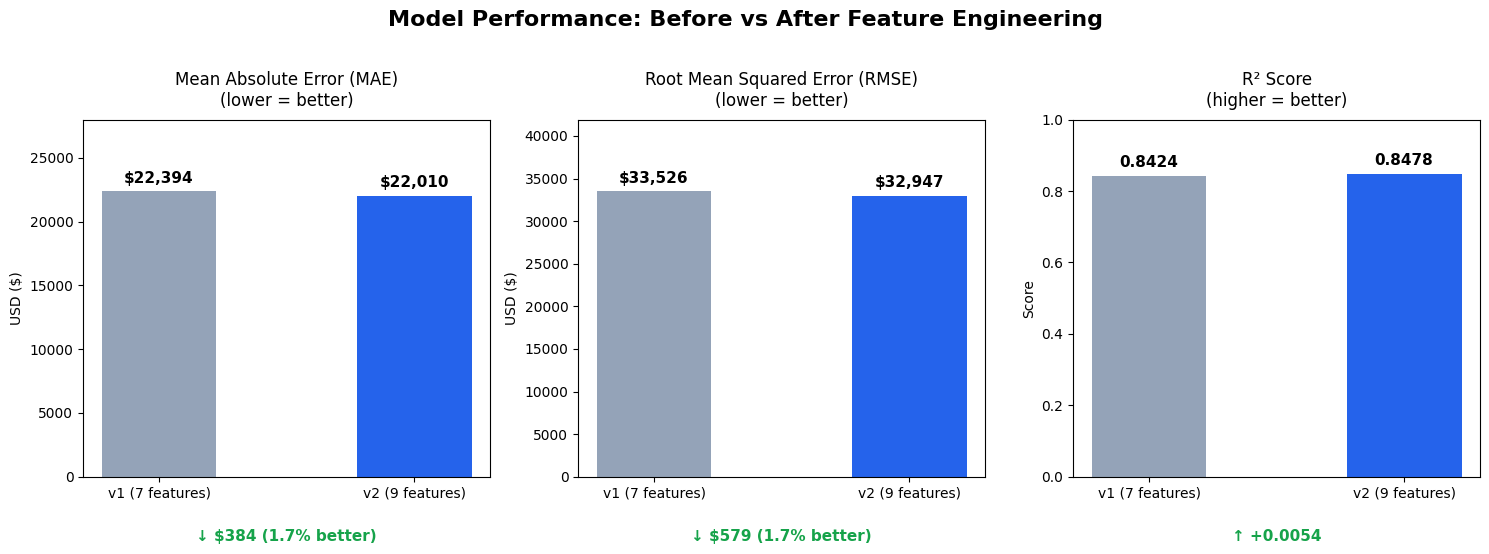

In [23]:
import matplotlib.pyplot as plt

# Color palette: v1 muted slate, v2 highlighted blue winner
colors = ['#94a3b8', '#2563eb']

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle('Model Performance: Before vs After Feature Engineering', fontsize=16, fontweight='bold', y=1.02)

# Subplot 1: MAE
ax1 = axes[0]
bars1 = ax1.bar(comparison_table.index, comparison_table['MAE'], color=colors, width=0.45)
ax1.set_title('Mean Absolute Error (MAE)\n(lower = better)', fontsize=12, pad=10)
ax1.set_ylabel('USD ($)')
ax1.set_ylim(0, max(comparison_table['MAE']) * 1.25)
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'${height:,.0f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
mae_diff = mae_rf_v1 - mae_rf_v2
mae_pct = (mae_diff / mae_rf_v1) * 100
ax1.text(0.5, -0.18, f'↓ ${mae_diff:,.0f} ({mae_pct:.1f}% better)', transform=ax1.transAxes,
         ha='center', fontsize=11, fontweight='bold', color='#16a34a')

# Subplot 2: RMSE
ax2 = axes[1]
bars2 = ax2.bar(comparison_table.index, comparison_table['RMSE'], color=colors, width=0.45)
ax2.set_title('Root Mean Squared Error (RMSE)\n(lower = better)', fontsize=12, pad=10)
ax2.set_ylabel('USD ($)')
ax2.set_ylim(0, max(comparison_table['RMSE']) * 1.25)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'${height:,.0f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
rmse_diff = rmse_rf_v1 - rmse_rf_v2
rmse_pct = (rmse_diff / rmse_rf_v1) * 100
ax2.text(0.5, -0.18, f'↓ ${rmse_diff:,.0f} ({rmse_pct:.1f}% better)', transform=ax2.transAxes,
         ha='center', fontsize=11, fontweight='bold', color='#16a34a')

# Subplot 3: R2
ax3 = axes[2]
bars3 = ax3.bar(comparison_table.index, comparison_table['R2'], color=colors, width=0.45)
ax3.set_title('R² Score\n(higher = better)', fontsize=12, pad=10)
ax3.set_ylabel('Score')
ax3.set_ylim(0, 1.0)
for bar in bars3:
    height = bar.get_height()
    ax3.annotate(f'{height:.4f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
r2_diff = r2_rf_v2 - r2_rf_v1
ax3.text(0.5, -0.18, f'↑ +{r2_diff:.4f}', transform=ax3.transAxes,
         ha='center', fontsize=11, fontweight='bold', color='#16a34a')

plt.tight_layout()
plt.show()


## Step 3 — Key Presentation Takeaways

### Summary & Insights
- **Feature engineering delivered measurable performance gains across all metrics.**
- Adding `HouseAge` and `TotalFlrSF` reduced the Mean Absolute Error (MAE) by **$384** (a **1.7%** reduction in prediction error) and increased the R² score from **0.8424** to **0.8478**.
- While the gain is modest, `TotalFlrSF` emerged as the single highest-correlated feature (+0.72) in the model, justifying its permanent inclusion in our production pipeline.